# Т-Интенсив. Управление рисками
## Август 2026

## Часть 1. График линейности признака по WoE.

В этой части домашки мы познакомимся с одним из основных инструментов для анализа переменных в модели логистической регрессии - графиком линейности. 

Кратко идею этого графика можно сформулировать так:
 - модель *линейной* регрессии корректно применять, если значение $y$ *линейно* связано со значением $x$. Иначе линрег не подходит для данной задачи и даст неверные результаты.
 - аналогичную проверку хочется сделать и для *логистической* регрессии. Но как проверить линейность, если таргет принимает всего два значения?
 - для этого необходимо преобразовать таргет: разбить признак на бакеты и в каждом бакете посчитать WoE
 - **линейность признака по WoE для логрега – аналог линейной связи признака и таргета для линрега**

Ниже пример признака с неплохой линейностью:

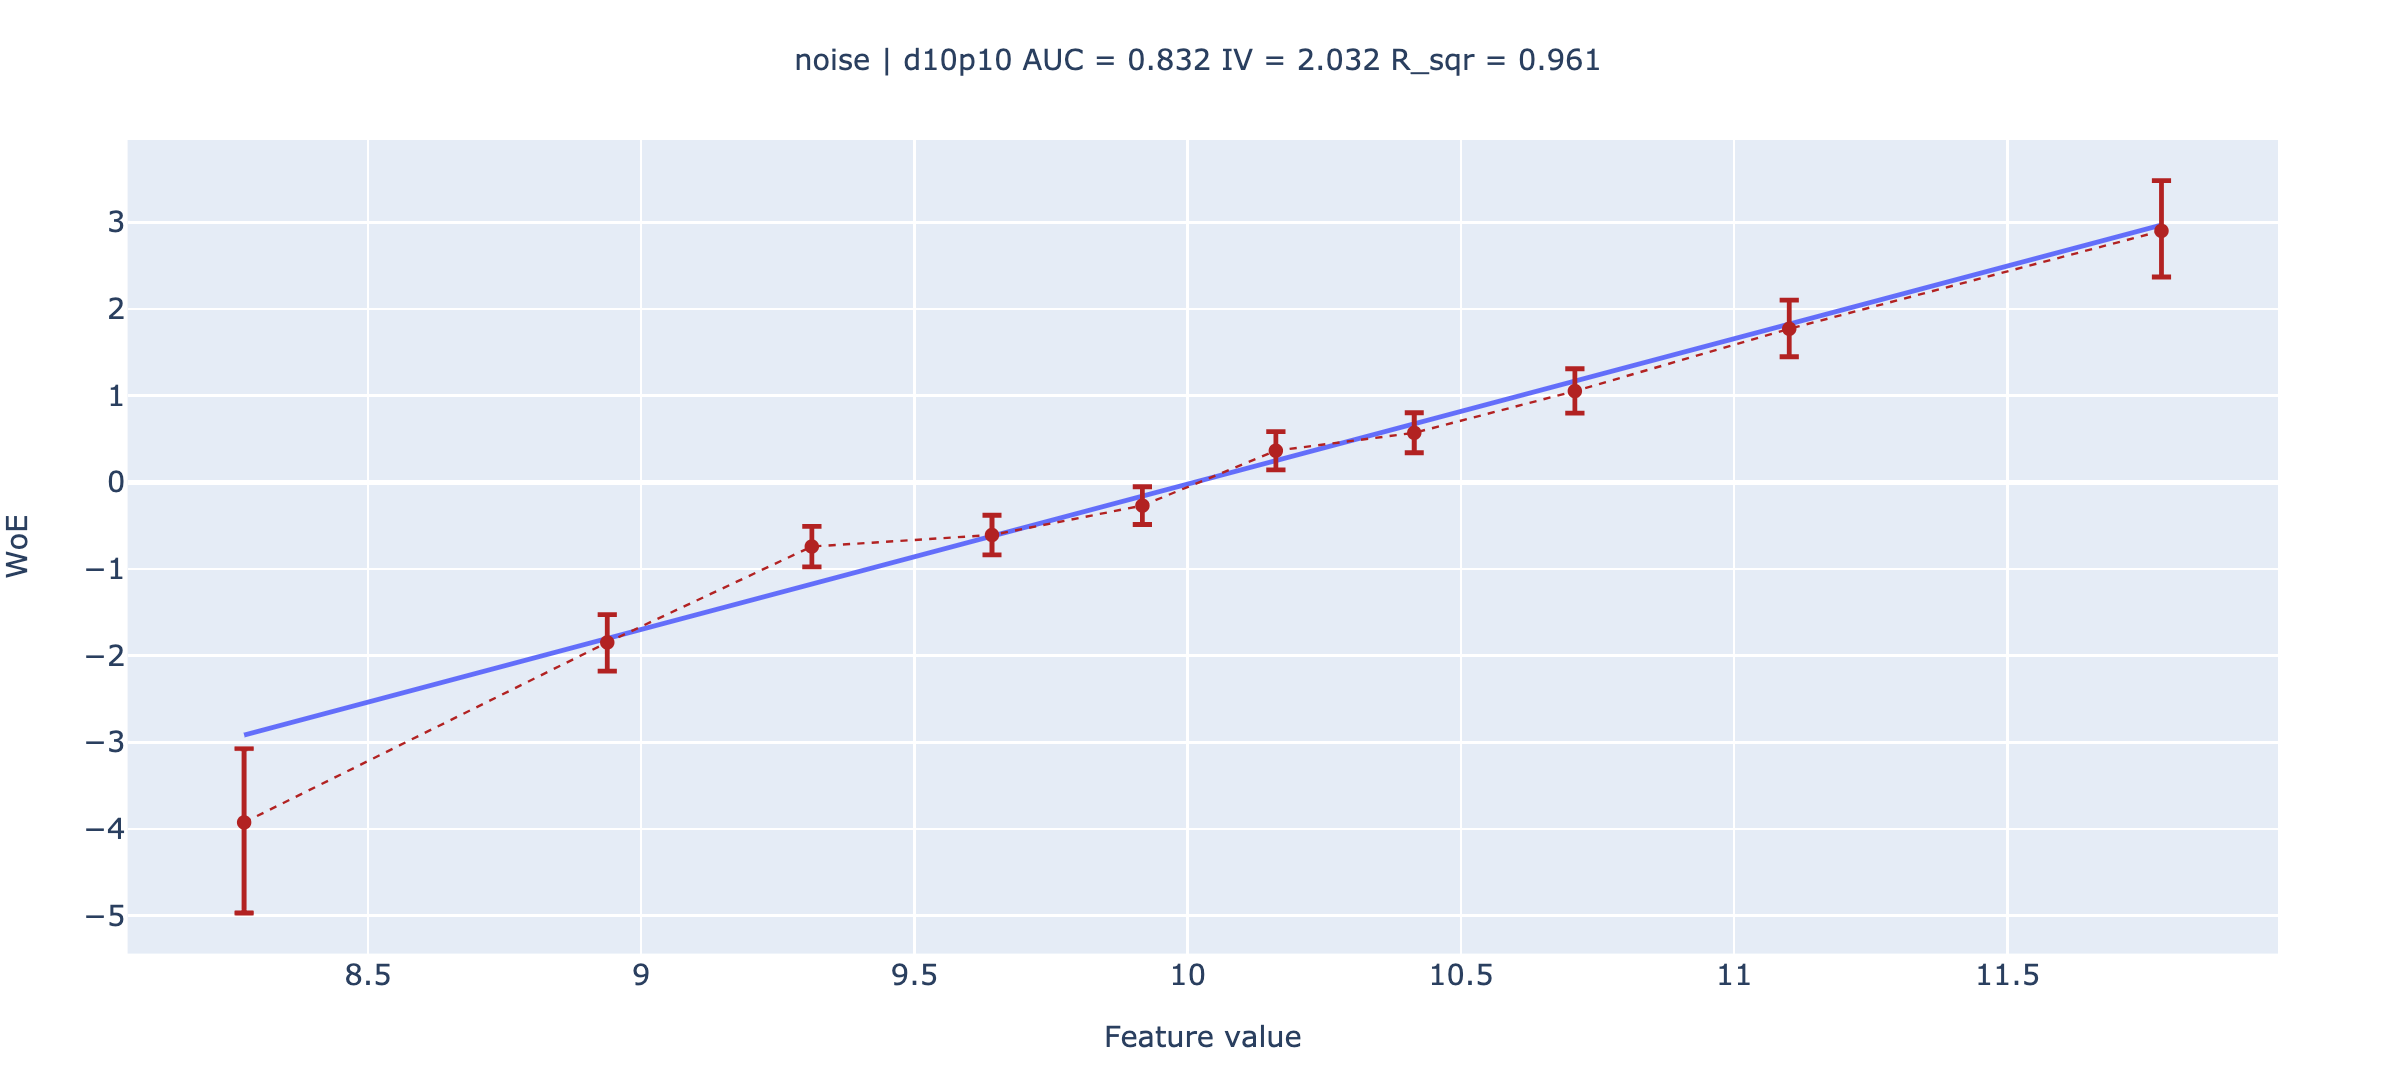

Нам нужно обратить внимание на 3 вещи:

**1. Фиолетовые точки с доверительными интервалами.**

Это WoE для каждого отдельного бакета. В идеале нам бы хотелось, чтобы **через эти точки можно было провести прямую линию** с небольшой погрешностью. Это и означает линейную взаимосвязь с таргетом.

**2. Синяя линия**

Попытка провести прямую линию через точки. Строится с помощью логистической регрессии на одной переменной. Затем предсказания переводятся в пространство WoE, отчего и получается прямая линия.

**3. Метрики в заголовке графика**

Метрики для признака:
 - roc auc, IV измеряют разделяющую способность переменной
 - $R^2$ измеряет *линейность взаимосвязи*. Признак считается линейным, если $R^2 \geq 0.95$

Далее напишем woe-line руками, чтобы в деталях разобраться, как он строится.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as sps
from typing import Union, Tuple

### Шаг 0: разбиение на бакеты

In [2]:
def calc_buckets(x : Union[np.ndarray, pd.Series], n_buckets : int) -> np.ndarray:
    """Разбивает массив значений признака x на 
    n_buckets бакетов"""

    x = pd.Series(x).reset_index(drop=True)
    buckets = x.rank(method="dense", pct=True) * n_buckets
    buckets = np.ceil(buckets) - 1   # np.floor дает другой результат для 5.0, 6.0 и т.д.
    buckets = np.array(buckets, dtype=np.int16)

    return buckets

In [3]:
# протестируйте calc_buckets

In [4]:
np.random.seed(0)
test_feature = np.random.normal(size=1000)
n_buckets = 10
test_buckets = calc_buckets(test_feature, n_buckets)

In [5]:
sorted(pd.Series(test_buckets).unique())

[np.int16(0),
 np.int16(1),
 np.int16(2),
 np.int16(3),
 np.int16(4),
 np.int16(5),
 np.int16(6),
 np.int16(7),
 np.int16(8),
 np.int16(9)]

In [6]:
pd.Series(test_buckets).value_counts().sort_index()

0    100
1    100
2    100
3    100
4    100
5    100
6    100
7    100
8    100
9    100
Name: count, dtype: int64

In [7]:
check = pd.DataFrame({"feature": test_feature, "bucket": test_buckets}).sort_values("feature")
check.head()

,feature,bucket
589,-3.046143,0
685,-2.834555,0
271,-2.772593,0
427,-2.739677,0
334,-2.659172,0


In [8]:
check.tail()

,feature,bucket
465,2.412454,9
734,2.497200,9
898,2.594425,9
494,2.696224,9
943,2.759355,9


### Шаг 1: расчет WoE по бакетам (3 балла)

Пусть $x_i \in \{ 0, 1\}^n$

$x_i$ - это вектор, состоящий из значений таргета *в одном бакете* $i$. 

Для бакета можно посчитать количество единиц $B_i$ (bads, выпавшие в дефолт) и количество нулей $G_i$ (goods).

$$
B_i = \sum_{j \in x_i} \mathbb{I} \{ j = 1\}\quad G_i = \sum_{j \in x_i} \mathbb{I} \{ j = 0\}
$$

Также число бэдов и гудов можно посчитать и **для всей выборки**: 

$$
% X = x_1 \cup x_2 \ldots \cup x_n
X = \{x_1,\; x_2\; \ldots\; x_n\}
$$

$$
B = \sum_{j \in X} \mathbb{I} \{ j = 1\}\quad G = \sum_{j \in X} \mathbb{I} \{ j = 0\}
$$

Тогда WoE можно посчитать как

$$
\text{WoE}_i(x) = \ln \Big ( \frac{B_i}{G_i} \Big ) - \ln \Big ( \frac{B}{G} \Big ) 
$$

**Задание**

Убедиться, что

$$
\text{WoE}_i(x) = \text{logit}(b_i) - \text{logit}(b)\quad  (1)
$$

где 

$$
b = \frac{B}{B + G}\quad \text{logit}(p) = \ln \Big (  \frac{p}{1 - p} \Big )
$$

В дальнейшем будем считать WoE по формуле $(1)$

In [9]:
from scipy.special import logit

def woe_transform(badrate : float, offset : float) -> float:
    """Считаем WoE для бакета с данным badrate и выборки
    с данным offset."""
    woe = logit(badrate) - offset
    return woe

### Доказательство 

Дано badrate всей выборки равное $b = \frac{B}{B+G}$, чтобы доказать введем ещё badrate  $i$-ого  бакета как долю дефолтов среди наблюдений конкретного бакета:

$$b_i = \frac{B_i}{B_i + G_i}$$


$$
\text{WoE}_i(x) = \text{logit}(b_i) - \text{logit}(b)\quad  (1)
$$


Если badrate $i$-ого бакета равен:

$$b_i = \frac{B_i}{B_i + G_i}$$

Тогда доля недефолтов в этом бакете будет равна:

$$1 - b_i = \frac{(B_i + G_i) - B_i}{B_i + G_i} = \frac{G_i}{B_i + G_i}$$

По определению logit это:

$$\text{logit}(b_i) = \ln\left(\frac{b_i}{1 - b_i}\right) = \ln\left(\frac{B_i / (B_i+G_i)}{G_i / (B_i+G_i)}\right) = \ln\left(\frac{B_i}{G_i}\right)$$

знаменатели $(B_i+G_i)$ сокращаются, и так аналогично для всей выборки, где $b = \frac{B}{B+G}$:

$$\text{logit}(b) = \ln\left(\frac{B}{G}\right)$$

Подставим оба результата:

$$\text{logit}(b_i) - \text{logit}(b) = \ln\left(\frac{B_i}{G_i}\right) - \ln\left(\frac{B}{G}\right)$$

Получается, результат совпадает с начальной формулой: 

$$\text{WoE}_i(x) = \ln\left(\frac{B_i}{G_i}\right) - \ln\left(\frac{B}{G}\right)$$

Следовательно, $\text{WoE}_i(x) = \text{logit}(b_i) - \text{logit}(b)$

Здесь и далее предлагается протестироать получившиеся функции. Нужно проверить, что
 - функция не ложится с ошибкой
 - возвращает то, что ожидается

In [10]:
# протестируй woe_transform

In [11]:
all_badrate = 0.10
offset = logit(all_badrate)

print("Если бакет равен среднему по выборке:", woe_transform(0.10, offset))
print("Бакет больше среднего:", woe_transform(0.45, offset))
print("Бакет меньше среднего:", woe_transform(0.05, offset))
print("Если на границе badrate = 0:", woe_transform(0.0, offset))
print("На другой границе badrate = 1:", woe_transform(1.0, offset))

Если бакет равен среднему по выборке: 0.0
Бакет больше среднего: 1.996553881874068
Бакет меньше среднего: -0.7472144018302211
Если на границе badrate = 0: -inf
На другой границе badrate = 1: inf


### Доверительные интервалы (3 балла)

Ниже представлен шаблон функции, которая будет считать доверительный интервал к нашим вычислениям. Можно воспользоваться любым способом, который вам больше нравится. Для идей можно посмотреть различные способы подсчета доверительного интервала [здесь](https://en.wikipedia.org/wiki/Binomial_proportion_confidence_interval).

**P. S.**
Для того, чтобы построить доверительный интервал к $WoE$, можно сначала построить его для величины  $b_i = \frac{B_i}{B_i+G_i}$, а потом применить ```woe_transform```. В свою очередь величина $b_i$ является параметром распределения Бернулли, который мы можем оценить классическими методами (см. ссылку выше)

In [12]:
def woe_ci(target : np.ndarray, buckets : np.ndarray, offset : float) -> Tuple[pd.Series]:
    """Для каждого бакета вычисляем WoE и доверительный
    интервал для него."""
    target = np.array(target)
    all_buckets = np.array(buckets)
    n_buckets = all_buckets.max() + 1

    z = sps.norm.ppf(0.975)  

    badrate = np.zeros(n_buckets)
    badrate_lower = np.zeros(n_buckets)
    badrate_upper = np.zeros(n_buckets)

    for i in range(n_buckets):
        y = target[all_buckets == i]
        n = len(y)
        p_hat = y.mean()

        center = (p_hat + z**2 / (2 * n)) / (1 + z**2 / n)
        indent_c = (z / (1 + z**2 / n)) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))

        badrate[i] = p_hat
        badrate_lower[i] = center - indent_c
        badrate_upper[i] = center + indent_c 

    # переходим от бэдрейта к woe
    woe = woe_transform(badrate, offset)
    woe_lower = woe_transform(badrate_lower, offset)
    woe_upper = woe_transform(badrate_upper, offset)

    return pd.Series(woe), pd.Series(woe_lower), pd.Series(woe_upper)

Я решила взять интервал Уилсона из предложенных по ссылке, так как, на мой взгляд он наиболее понятный по расчетам, и к тому же, ведет себя устойчиво на краях, что может быть важно, так как бэдрейты могут быть и 0, и 1.

### Шаг 2: расчет линейной интерполяции (1 балл)

In [13]:
from sklearn.linear_model import LogisticRegression

def calc_line(values : np.ndarray, target : np.ndarray, mean_feature : np.ndarray, offset : float) -> np.ndarray:
    """Строим линейную интерполяцию для WoE."""

    model = LogisticRegression()
    model.fit(values.reshape(-1, 1), target)

    proba = model.predict_proba(mean_feature.reshape(-1, 1))[:, 1]

    line = woe_transform(proba, offset)
    return line

In [14]:
# протестируйте calc_line

In [15]:
np.random.seed(0)
test_target = np.random.binomial(1, 0.1, size=1000)

In [16]:
mean_test = np.array([test_feature[test_buckets == i].mean() for i in range(n_buckets)])
offset_test = logit(test_target.mean())

calc_line(test_feature, test_target, mean_test, offset_test)

array([-0.06709547, -0.03929841, -0.02581728, -0.01468004, -0.00502894,
        0.00455296,  0.01464504,  0.02567606,  0.0405397 ,  0.06966879])

### Шаг3: собираем результаты по бакетам в один словарь

In [17]:
def calc_buckets_info(values : np.ndarray, target : np.ndarray, buckets : np.ndarray) -> dict:
    """Для каждого бакета расчитывает
     - среднее значение признака
     - линейную интерполяцию в пространстве woe
     - значение woe и доверительный интервал для него"""
    
    n_buckets = buckets.max() + 1
    mean_feature = np.array([values[buckets == i].mean() for i in range(n_buckets)])

    offset = logit(target.mean())

    line = calc_line(values, target, mean_feature, offset)
    woe, woe_lower, woe_upper = woe_ci(target, buckets, offset)

    buckets_info = {
        "mean_feature" : mean_feature,
        "line"         : line,
        "woe"          : woe,
        "woe_lower"    : woe_lower,
        "woe_upper"    : woe_upper
    }

    return buckets_info

In [18]:
# протестируйте calc_buckets_info

In [19]:
calc_buckets_info(test_feature, test_target, test_buckets)

{'mean_feature': array([-1.7679755 , -1.05761653, -0.71310373, -0.42848952, -0.18185379,
         0.06301342,  0.32091838,  0.6028183 ,  0.98266137,  1.72706054]),
 'line': array([-0.06709547, -0.03929841, -0.02581728, -0.01468004, -0.00502894,
         0.00455296,  0.01464504,  0.02567606,  0.0405397 ,  0.06966879]),
 'woe': 0   -0.202300
 1    0.210376
 2   -0.331012
 3   -0.085890
 4   -0.331012
 5    0.020594
 6    0.296045
 7    0.210376
 8    0.210376
 9   -0.202300
 dtype: float64,
 'woe_lower': 0   -0.874443
 1   -0.364472
 2   -1.038610
 3   -0.728117
 4   -1.038610
 5   -0.595999
 6   -0.261555
 7   -0.364472
 8   -0.364472
 9   -0.874443
 dtype: float64,
 'woe_upper': 0    0.469843
 1    0.785225
 2    0.376585
 3    0.556338
 4    0.376585
 5    0.637187
 6    0.853645
 7    0.785225
 8    0.785225
 9    0.469843
 dtype: float64}

### Шаг 4: считаем метрики признака (3 балла)

Рассчитаем также несколько метрик, чтобы судить о качестве признака не только по картинкам. 

Приведем формулу для IV:

$$
\text{IV}(x) = \sum_{i = 1}^{n}\Big ( \frac{B_i}{B} - \frac{G_i}{G} \Big ) \times \text{WoE}_i
$$

**Вопрос:** зачем считать ранжирующую силу признака двумя способами? Какую дополнительную информацию может дать IV относительно roc auc?

Для того чтобы максимально обширно оценить данные. Смотреть на оба показателя полезнее, так как они по-разному оценивают данные. ROC AUC перебирает разные пороги и показывает ранжирование наблюдений. По сути, на сколько точно признак разделяет классы (1 и 0). Эта метрика будет смотреть только на порядок, правильно ли упорядоченны наблюдения от меньших, к большим (к примеру, насколько дефолтные объекты в среднем оказываются выше по этому ранжированию, чем недефолтные), но сами по себе значения она не оценит. 

А IV считается по бакетам, для каждого берёт разницу между долей всех дефолтов, которая приходится на этот бакет, и долей всех недефолтов, которая приходится на тот же бакет, и умножает эту разницу на WoE этого бакета, а потом суммируем по всем бакетам. И уже эта метрика покажет, есть ли в каком-то бакете перевес дефолтов относительно остальных бакетов, или наоборот, если бакет почти не отличается от других (минимальная разница, ниже определенного порога), то этот признак бесполезный. 

Получается, IV может дать дополнительную информацию относительно ROC AUC в сравнении двух этих показателей. Как мы обсуждали на лекции, если сам по себе ROC AUC удовлетворительный, а IV низкий (возможно бедрейт в бакетах изменяется слабо), это повод задуматься, что направление правильное, а сама сила от эффекта небольшая. Или если оба показателя сильно расходятся, то следует обратить внимание на форму зависимости. Весь найденный эффект признака может быть держится на каком-то одном бакете или сосредоточен в хвосте распределения, а не на устойчивой связи в диапазоне.

In [20]:
from sklearn.metrics import roc_auc_score

def calc_plot_title(
        values : np.ndarray,
        target : np.ndarray,
        buckets : np.ndarray
    ) -> str:
    """Считает для признака roc auc, IV, R^2"""
    auc = roc_auc_score(target, values)

    n_buckets = buckets.max() + 1
    B = target.sum()
    G = len(target) - B

    offset = logit(target.mean())
    woe, woe_lower, woe_upper = woe_ci(target, buckets, offset)
    woe = np.array(woe)

    IV = 0.0
    for i in range(n_buckets):
        y_i = target[buckets == i]
        B_i = y_i.sum()
        G_i = len(y_i) - B_i
        IV += (B_i / B - G_i / G) * woe[i]

    # Взвешенный R^2 
    # X - среднее в бакете, Y - woe в бакете, вес – число наблюдений в бакете

    mean_feature = np.array([values[buckets == i].mean() for i in range(n_buckets)])
    weights = np.array([(buckets == i).sum() for i in range(n_buckets)])

    x_mean = np.average(mean_feature, weights=weights)
    y_mean = np.average(woe, weights=weights)

    covari_xy = np.average((mean_feature - x_mean) * (woe - y_mean), weights=weights)
    vari_x = np.average((mean_feature - x_mean) ** 2, weights=weights)
    vari_y = np.average((woe - y_mean) ** 2, weights=weights)

    R_sqr = covari_xy ** 2 / (vari_x * vari_y)

    plot_title = (        
        f"AUC = {auc:.3f} "
        f"IV = {IV:.3f} "
        f"R_sqr = {R_sqr:.3f} "
    )

    return plot_title

In [21]:
# протестируйте calc_plot_title

In [22]:
calc_plot_title(test_feature, test_target, test_buckets)

'AUC = 0.523 IV = 0.052 R_sqr = 0.059 '

### Шаг 5: собираем все в одну функцию и строим график

In [23]:
# в этот код можно не въезжать :)
import plotly.graph_objects as go

def make_figure(buckets_info : dict, plot_title : str) -> go.Figure:
    """Строит график линейности."""
    fig = go.Figure()

    # общие настройки
    title = dict(
        text=plot_title,
        y=0.95,
        x=0.5,
        font=dict(size=12),
        xanchor="center",
        yanchor="top"
    )
    margin = go.layout.Margin(
        l=50,
        r=50,
        b=50,
        t=60
    )

    fig.add_trace(
        go.Scatter(
            x=buckets_info["mean_feature"],
            y=buckets_info["line"],
            mode='lines',
            name="interpolation_line",
            showlegend=False
        )
    )

    fig.add_trace(
        go.Scatter(
            x=buckets_info["mean_feature"],
            y=buckets_info["woe"],
            line=dict(
                color='firebrick',
                width=1,
                dash='dot'
            ),
            error_y=dict(
                type='data',
                symmetric=False,
                array=buckets_info["woe_upper"],
                arrayminus=buckets_info["woe_lower"]
            ),
            name="WoE",
            showlegend=False)
    )

    fig.update_layout(
        width=1000,
        height=450,
        xaxis_title=dict(
            text='Feature value',
            font=dict(size=12)
        ),
        yaxis_title=dict(
            text="WoE",
            font=dict(size=12)
        ),
        title=title,
        margin=margin
    )

    return fig

In [24]:
def woe_line(
        values : np.ndarray,
        target : np.ndarray,
        n_buckets : int
    ) -> go.Figure:
    """График линейности переменной по WoE."""
    buckets : np.ndarray = calc_buckets(values, n_buckets)
    buckets_info : pd.DataFrame = calc_buckets_info(values, target, buckets)
    plot_title : str = calc_plot_title(values, target, buckets)
    fig = make_figure(buckets_info, plot_title)
    return fig

Чтобы протестировать реализацию, сгенерируем синтетические данные:

In [25]:
sample_size = int(1e4)
noise_std = 1.

df = pd.DataFrame()
y = np.array(sample_size // 2 * [0] + sample_size // 2 * [1])
df['target']  = y

np.random.seed(89)
x = np.concatenate([sps.norm(0, noise_std).rvs(size = sample_size // 2), sps.norm(1, noise_std).rvs(size = sample_size // 2)])
df['feature'] = x

<Axes: xlabel='feature', ylabel='Count'>

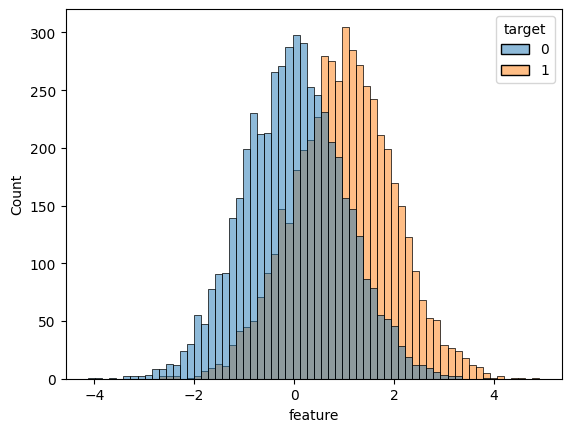

In [26]:
sns.histplot(df, x = 'feature', hue = 'target')

In [27]:
# запустите после того, как реализуете все функции 
woe_line(values=x, target=y, n_buckets=5)

### Эксперименты (2 балла)

#### №1 

Как будут меняться график, метрики разделяющей способности и $R^2$ при изменении дисперсии шума (параметр `noise_std`)? 

In [28]:
for val_noise_std in [0.3, 1.0, 2.0, 4.0]:
    sample_size = int(1e4)
    y_exp = np.array(sample_size // 2 * [0] + sample_size // 2 * [1])

    np.random.seed(89)
    x_exp = np.concatenate([
        sps.norm(0, val_noise_std).rvs(size=sample_size // 2),
        sps.norm(1, val_noise_std).rvs(size=sample_size // 2)
    ])

    figur = woe_line(values=x_exp, target=y_exp, n_buckets=5)
    figur.show()

При изменении дисперсии шума на графике не наблюдается кардинальных изменений. Точки по WoE примерно на том же месте остаются и сама форма зависимости не меняется. Можно сказать, что изменяется наклон линии. На графике 1 шум = 0.3 (самый маленький), при этом AUC = 0.990, IV = 9.001, R² = 0.998. А WoE самая широкая по размаху и это самый большой диапазон WoE среди остальных графиков. Хотя небольшое изменение признака, но оно уже даёт большое изменение по WoE. На графике 2 шум = 1, AUC = 0.760, IV = 0.882, R² = 0.999. Диапазон WoE более узкий (примерно от - 3 до + 3). А линия более пологая, чем на первом графике. Далее график 3 с шумом = 2, AUC = 0.638, IV = 0.226, R² = 0.995. Диапазон WoE становится ещё уже    (примерно от - 1 до + 1.5). Заметно, что и линия становится площе. И последний, 4-ый график с шумом = 4, он же самый большой шум, AUC = 0.57, IV = 0.058, 

Что касается метрик разделяющей способности, на первом графике AUC близок к 1 (0.990), что соответствует маленькому шуму = 0.3, а IV = 9.001, значит классы здесь почти не накладываются друг на друга. На втором графике шум = 1, AUC = 0.76 и IV = 0.882, что сильно ниже, чем на первом графике, то есть признак хуже разделяет классы, так как шум увеличился, а распределения двух классов стали перекрываться. Следующий график 3 с шумом = 2, AUC = 0.638, IV = 0.226. AUC снижается, IV падает примерно в 4 раза по сравнению со вторым графиком. И заключительный график 4 с самым большим шумом = 4, AUC = 0.570, IV = 0.058. Здесь видно, что AUC почти = 0.5 (случайное угадывание), а IV стремится к нулю, то есть признак почти ничем не отличается от других и  не несёт релевантной информации о таргете.

R² на всех четырёх графиках достаточно высокий (0.994 - 0.999), значит линейность связи сохраняется, только меняется её сила. Самое высокое значение на графике 2 (0.999), а самое низкое на графике 4 (0.994). Хотя разницы практически нет, максимум 0.005. Более того, как я описывала выше, сильнее всего упали AUC и IV между теми же графиками.


#### №2 

Запустите функцию с `values=x ** 2`. Как по графику определить эту ситуацию? Что нужно делать в таком случае?

In [29]:
woe_line(values=x ** 2, target=y, n_buckets=5)

По графику можно определить ситуацию values = x², если посмотреть на точки WoE. Как видно на графике, они перестают лежать на прямой линии. При этом синяя линия интерполяции уже не проходит через них с минимальным отступом. Заметно меняется форма графика, тогда как на предыдущих линия шла стабильно монотонно вверх. Также по метрикам можно увидеть, что резко падает R² в сравнении с изначальным признаком. 
В таком случае нужно вернуть исходный признак без квадратичного вида, так как до он был линейно связан с таргетом и его можно было использовать напрямую в логистической регрессии. Есть идея всё таки оставить так, но только в качестве дополнительного, а не основного признака. То есть сделать многомерную модель, в которой логистическая регрессия учтет и тот, и другой признак. (Более сложный вариант построить дополнительные бакеты для отрицательной и положительной частей признака).

#### №3

Запустите функцию с `values=np.exp(x)`. Как по графику определить эту ситуацию? Что нужно делать в таком случае?

In [30]:
woe_line(values=np.exp(x), target=y, n_buckets=5)

По графику можно определить ситуацию values = np.exp(x) снова посмотрев на точки. Они будут расти, но при этом их форма будет другой, вместо прямой линией появится изогнутая кривая. Заметно, что большинство точек будут прижаты влево на маленьком расстоянии друг от друга. Тогда как справа, наоборот, точки сильно отдалятся друг от друга. И будет вырисовывыться хвост распределения из-за такого скачка. Сам масштаб оси x стал нелинейным. Синяя линия интерполяции перестанет ровно проходить через фиолетовые точки. R² снова упадёт по сравнению с исходным признаком. Однако AUC и IV почти не изменятся. В целом, это объясняется тем, что обе метрики зависят от порядка и состава бакетов, а экспонента порядок не меняет. В таком случае стоит попробовать подобрать обратное монотонное преобразование, чтобы разгладить кривую линию. Можно попробовать  взять от признака логарифм (np.log(values)), так как он поможет вернуть исходный линейный масштаб признака. К тому же, если наблюдается нелинейность, но при этом монотонная кривая, можно перебрать все подходящие монотонные преобразования (помимо логарифма), к примеру, квадратный корень или преобразование Бокса-Кокса. Протестировать и применить тот, который распрямит график снова в прямую линию. 

## Часть 2. Строим ЛогРег. (8 баллов)

В этом пунтке попробуем применить все наши навыки 

Скачайте датасет на EDU. Пароль вы найдете в телеграм-канале курса, в посте с анонсом домашки.

In [31]:
df = pd.read_csv('logreg_hw_5-068b58c1-e048-4e27-a0d3-be18839887c2.csv', index_col=0)
df

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,d4p12
0,-1.444709,3.554779,1.308371,-0.000119,0.029628,3.829880,1,8.825418,3.829880,11.565953,-513.014565,-1.072893,7.936545,0.047069,B,1
1,1.132531,-0.207661,-2.142882,0.062686,0.859062,6.189545,1,3.453220,6.189545,4.935665,-39.351891,3.409855,17.015210,0.029288,A,0
2,1.268781,-0.243999,10000.000000,0.339225,0.614599,12.503629,1,-10.116061,12.503629,6.234414,-4.993050,3.121126,4.878602,0.237255,A,0
3,-1.278475,-2.579890,5.050763,-0.938956,0.090461,-1.080041,1,6.780814,-1.080041,2.682539,-509.273095,-1.242741,20.293025,0.907788,B,0
4,3.507807,0.152661,-8.905005,0.067646,0.216199,1.367184,1,-10.638134,1.367184,6.881602,-2.034797,2.814972,7.352399,0.276854,A,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-3.061422,-0.163832,4.812768,-0.949937,0.224437,5.263508,1,-9.959913,5.263508,5.294558,-524.265291,-1.648415,5.410059,0.855190,B,0
99996,0.222451,-0.273191,0.380895,0.860607,0.950708,0.581767,1,-1.645952,0.581767,5.571499,-13.499956,3.386865,92.903615,0.006668,A,1
99997,1.078498,0.339526,-5.184847,0.242072,0.854085,0.995075,1,-5.565932,0.995075,-0.433263,3.928387,3.290285,1.233853,0.160933,A,1
99998,-1.431421,-0.605388,2.466023,-0.056519,0.736255,2.980562,1,-4.517188,2.980562,10.812813,-507.593408,-1.398568,1904.246147,0.077164,B,1


Как вы выдите, ```feature_1, ..., feature_14``` - числа 
```feature_15``` - категориальная фича

### Задание 0. EDA.

Как бы вы начали знакомиться с данными до построения модели? Постройте 3-5 графиков / таблиц, чтобы передать основную информацию о датасете.

In [32]:
df.columns

Index(['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5',
       'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10',
       'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15',
       'd4p12'],
      dtype='object')

При знакомстве с данными до построения модели можно посмотреть разные меры разброса по описанию: минимум, максимум, среднее, квартили, стандартное отклонение; а также на общее количество строк и столбцов, тип данных числовой/категориальный, количество непустых значений по каждому столбцу; для нашей задачи ещё полезно будет увидеть баланс классов, то есть какая доля наблюдений относится к дефолту / недефолту; ещё лучше посмотреть данные на графике, мне нравится ящик с усами, так почти всегда нагляднее видно распределение, медиану, выбросы и т.д. Ну и добивочно можно посмотреть, что происходит на графике у каждого отдельного признака, его форму распределения для класса 1 и 0. Так сразу будет видно, если распределения сильно смещены друг от друга по какому-то признаку или какой признак бесполезный и его распределения совпадают. Это поможет возможно сразу очистить его для дальнейших действий. 

In [33]:
df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,d4p12
count,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,1.000000e+05,100000.000000
mean,-0.004065,-0.198827,-6.283870,-1.251609e-01,1.001067,2.990486,0.900280,-2.514795,2.990486,3.640370,-256.924907,1.013153,9.969348e+02,2.885691e-01,0.425370
std,2.625003,169.576125,2344.152317,5.900464e-01,1.003677,3.997014,0.299628,5.009291,3.997014,4.977886,260.742462,2.314468,4.699415e+03,3.785086e-01,0.494401
min,-54.598150,-38296.171946,-10000.000000,-1.999985e+00,0.000009,-18.732375,0.000000,-26.496544,-18.732375,-16.847030,-1012.820365,-9.210340,1.666947e-19,6.195140e-11,0.000000
25%,-1.011666,-0.385200,-4.215224,-2.219215e-01,0.287134,0.288999,1.000000,-5.893561,0.288999,0.270052,-506.548930,-1.262413,3.451754e+00,1.371482e-03,0.000000
50%,-0.058406,-0.072894,0.003200,-2.735552e-09,0.694543,3.001134,1.000000,-2.511154,3.001134,3.669848,-282.922772,-0.800022,2.341854e+01,4.439380e-02,0.000000
75%,1.004057,0.395806,4.255211,1.096505e-01,1.383918,5.688353,1.000000,0.859395,5.688353,6.984301,-0.080408,3.344923,1.536384e+02,6.085319e-01,1.000000
max,39.011329,20133.753873,10000.000000,9.999525e-01,11.629614,21.549778,1.000000,19.258719,21.549778,24.764462,446.685530,3.951220,3.729609e+05,1.000000e+00,1.000000


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   feature_1   100000 non-null  float64
 1   feature_2   100000 non-null  float64
 2   feature_3   100000 non-null  float64
 3   feature_4   100000 non-null  float64
 4   feature_5   100000 non-null  float64
 5   feature_6   100000 non-null  float64
 6   feature_7   100000 non-null  int64  
 7   feature_8   100000 non-null  float64
 8   feature_9   100000 non-null  float64
 9   feature_10  100000 non-null  float64
 10  feature_11  100000 non-null  float64
 11  feature_12  100000 non-null  float64
 12  feature_13  100000 non-null  float64
 13  feature_14  100000 non-null  float64
 14  feature_15  100000 non-null  object 
 15  d4p12       100000 non-null  int64  
dtypes: float64(13), int64(2), object(1)
memory usage: 13.0+ MB


In [35]:
df['d4p12'].value_counts(normalize=True)

d4p12
0    0.57463
1    0.42537
Name: proportion, dtype: float64

In [36]:
import matplotlib.pyplot as plt

In [37]:
numeric_cols = [c for c in df.columns if c.startswith('feature') and c != 'feature_15']

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(1, 0, 'feature_1'),
  Text(2, 0, 'feature_2'),
  Text(3, 0, 'feature_3'),
  Text(4, 0, 'feature_4'),
  Text(5, 0, 'feature_5'),
  Text(6, 0, 'feature_6'),
  Text(7, 0, 'feature_7'),
  Text(8, 0, 'feature_8'),
  Text(9, 0, 'feature_9'),
  Text(10, 0, 'feature_10'),
  Text(11, 0, 'feature_11'),
  Text(12, 0, 'feature_12'),
  Text(13, 0, 'feature_13'),
  Text(14, 0, 'feature_14')])

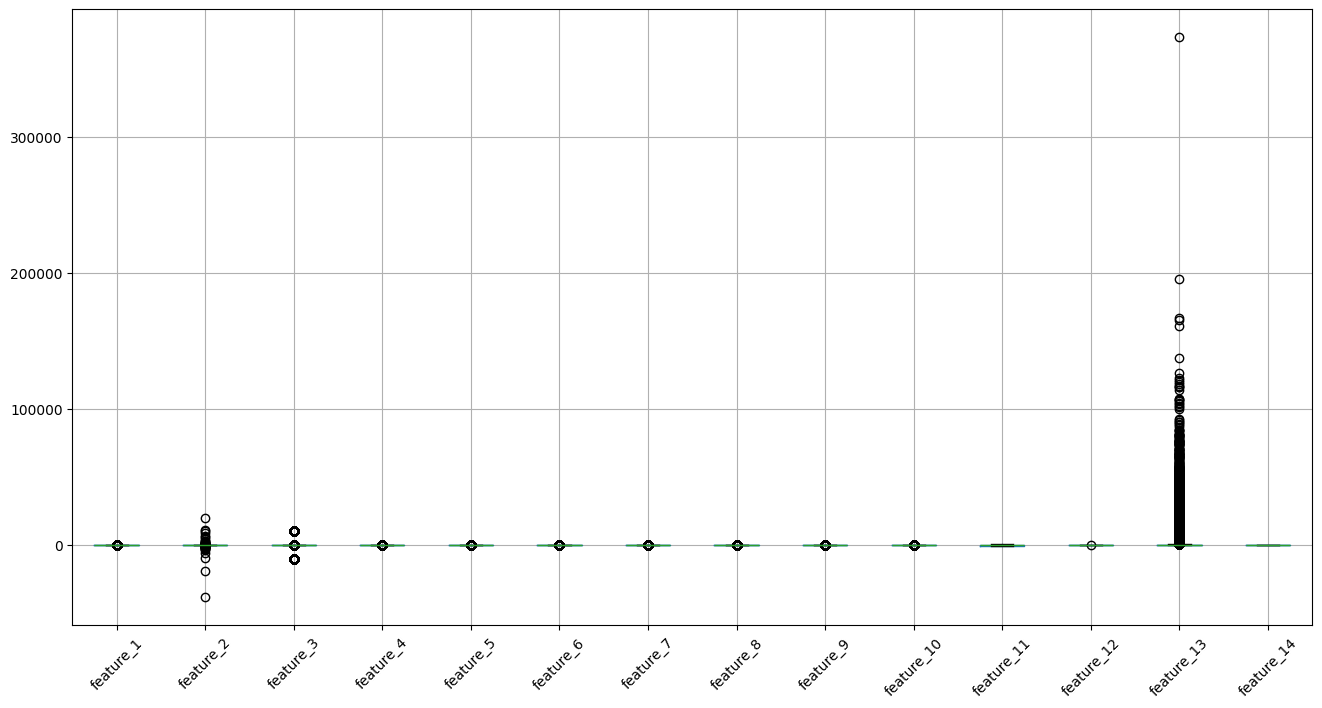

In [38]:
plt.figure(figsize=(16, 8))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)

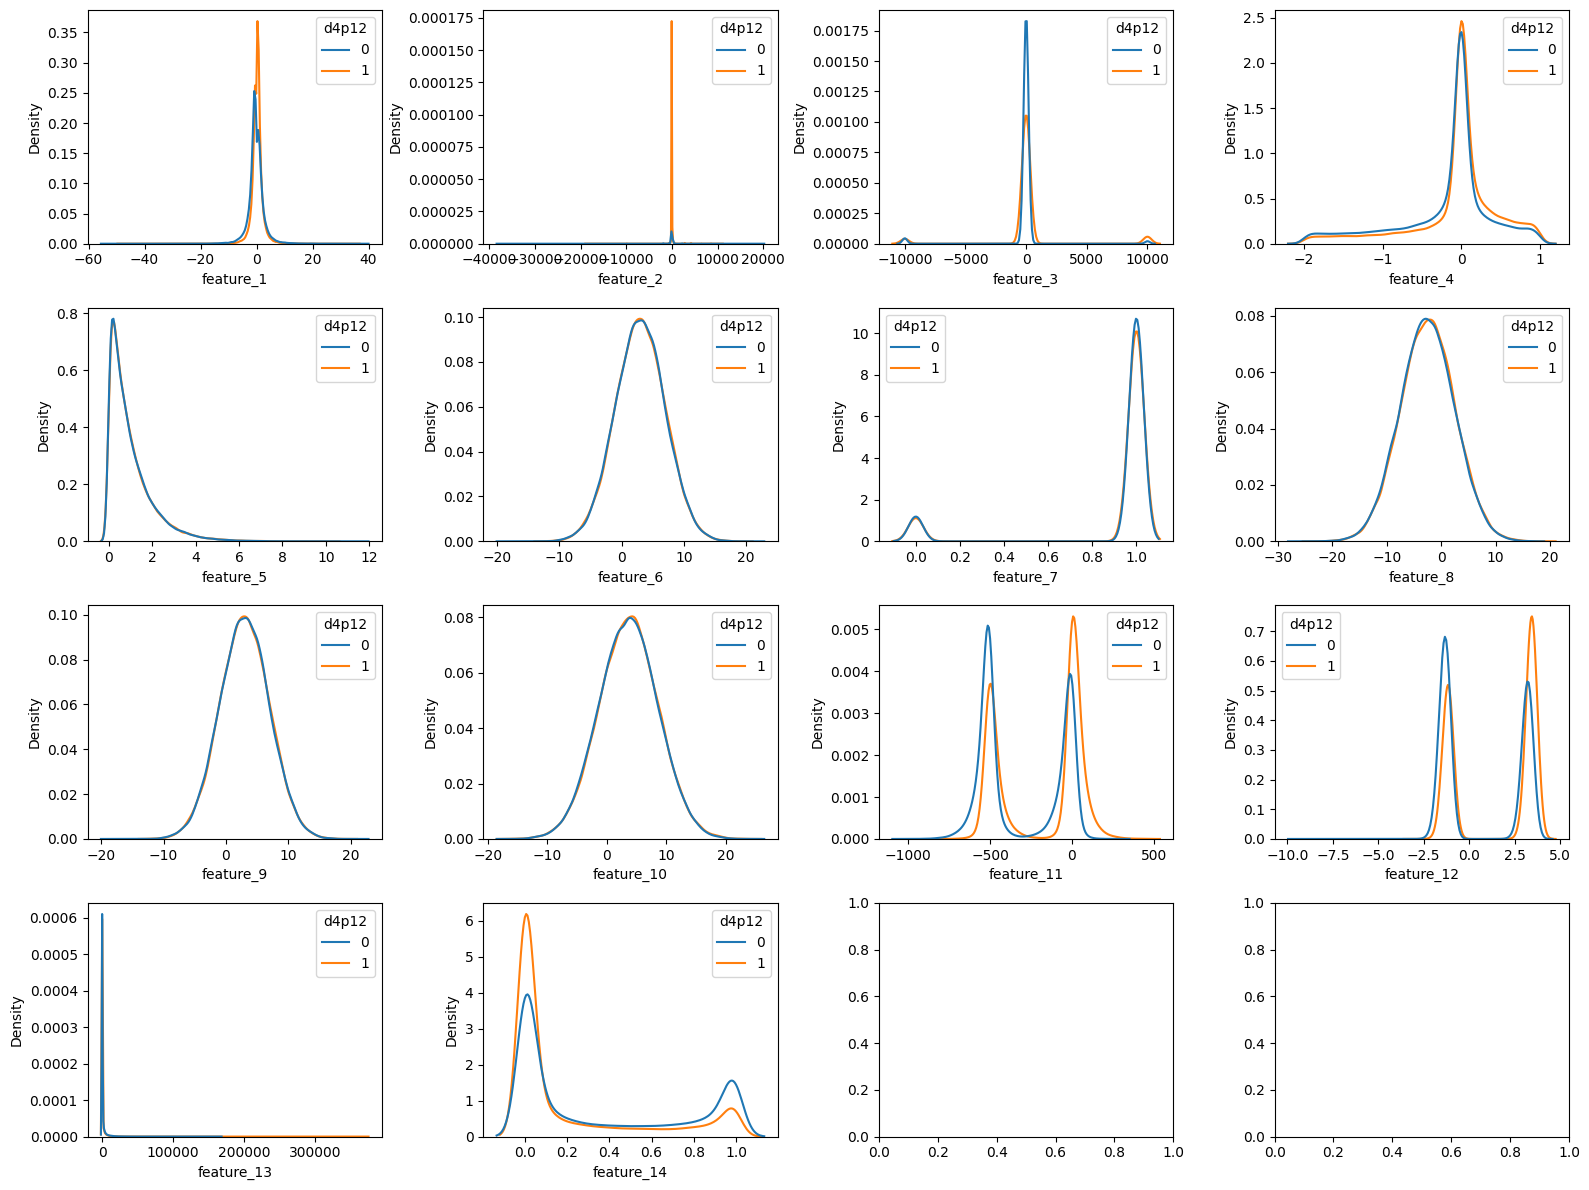

In [39]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, col in enumerate(numeric_cols):
    sns.kdeplot(data=df, x=col, hue='d4p12', ax=axes[i // 4, i % 4], common_norm=False)
plt.tight_layout()

Вот как раз тут видно, что 2-ой признак очень слабый, его распределения наложились друг на друга. Он явно несет больше шума, чем информации. В целом, 6 и 9 тоже с неразличимыми классами. А самый четкий 11 признак, оба класса в явном виде на графике с топами примерно в -500 и в 0.

### Задание 1. Бейзлайн.

Попробуйте построить ЛогРег только на числовых данных. Для этого разбейте датасет на трейн и тест (80/20). Перед обучением логрега стандартизуйте переменные. Это может быть полезно для численной устойчивости алгоритмов оптимизации.

Для этой модели и всех дальнейших:

1. Получилась ли модель линейной? Постройте график линейности на трейне и на тесте и сделайте вывод.
2. Расчитайте AUC и IV на трейне и на тесте. Что можно сказать о переобучении?

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

num_features = [col for col in df.columns if col.startswith('feature') and col != 'feature_15']
target_col = 'd4p12'

X = df[num_features]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [43]:
train_score = model.decision_function(X_train_scaled)
woe_line(values=train_score, target=y_train.values, n_buckets=10)

In [44]:
test_score = model.decision_function(X_test_scaled)
woe_line(values=test_score, target=y_test.values, n_buckets=10)

In [45]:
train_buckets = calc_buckets(train_score, 10)
train_title = calc_plot_title(train_score, y_train.values, train_buckets)
print("Train:", train_title)

test_buckets = calc_buckets(test_score, 10)
test_title = calc_plot_title(test_score, y_test.values, test_buckets)
print("Test:", test_title)

Train: AUC = 0.705 IV = 0.592 R_sqr = 0.974 
Test: AUC = 0.714 IV = 0.637 R_sqr = 0.983 


1. После построения графика линейности на трейн и тест, могу сказать, что модель получилась линейной на обеих выборках. На трейне R² = 0.974, на тесте R² = 0.983, а точки WoE лежат очень близко с синей линией интерполяции по всему диапазону значений.

2. Переобучения нет по AUC. Значения на трейне и тесте очень близки друг к другу, даже на тесте выше на 0.009. Тем более, наша выборка большая, 100 000 наблюдений, + это простая линейная модель с 15 параметрами, она не склонна к выраженному переобучению.

### Задание 2. Добавляем категориальную переменную.

Повторите задание 1, включив в модель категориальную переменную (например, с помощью one-hot encoding).

Улучшилось ли качество?

In [46]:
df_encod = pd.get_dummies(df, columns=['feature_15'], drop_first=True)

categ_dummy_c = [c for c in df_encod.columns if c.startswith('feature_15_')]
features_for_2 = num_features + categ_dummy_c

X2 = df_encod[features_for_2]
y2 = df_encod[target_col]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

In [47]:
model_2 = LogisticRegression()
model_2.fit(X2_train_scaled, y2_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [48]:
train_score_2 = model_2.decision_function(X2_train_scaled)
woe_line(values=train_score_2, target=y2_train.values, n_buckets=10)

In [49]:
test_score_2 = model_2.decision_function(X2_test_scaled)
woe_line(values=test_score_2, target=y2_test.values, n_buckets=10)

In [50]:
train_buckets_2 = calc_buckets(train_score_2, 10)
train_title2 = calc_plot_title(train_score_2, y2_train.values, train_buckets_2)
print("Train:", train_title2)

test_buckets2 = calc_buckets(test_score_2, 10)
test_title2 = calc_plot_title(test_score_2, y2_test.values, test_buckets2)
print("Test:", test_title2)

Train: AUC = 0.860 IV = 2.262 R_sqr = 0.982 
Test: AUC = 0.860 IV = 2.272 R_sqr = 0.982 


Как мы видим, качество модели действительно улучшилось. AUC на тесте вырос на 0,146, так как на 1 модели был = 0.714, а на 2 модели = 0.860. IV увеличился ещё сильнее, на 1.635, с 0.637 у 1 модели до 2.272 у 2 модели. Это кстати подчеркивает информативность категориальной переменной для модели. Или она даже подозрительно полезная, возможно стоило бы проверить есть ли утечка данных. 

Если продолжать отвечать на вопросы из Задания 1 только для этой 2 модели: 
1. Данная модель тоже линейная. R² = 0.982 и на трейне, и на тесте. В целом, ничего и не должно было по линейности поменяться, так как это не зависит напрямую от добавления категориальной переменной. 

2. Получилось так, что AUC и IV на трейне и на тесте одинаковые, соответственно нет переобучения. То есть в целом метрики выросли с добавлением категориальной фичи, но все осталось вполне устойчивым в модели.

### Задание 3. Линеаризация переменных.

На самом деле, категориальные переменные можно учитывать в моделях совсем по-другому. С их помощью можно выделить в модели сегменты. Каждому сегменту соответствует своя модель (в нашем случае логрег). 

Примером такой сегментации может стать сегментация по наличию кредитной истории. В этом случае на разных сегментах будут не просто отдельные модели, но и даже разный изначальный набор признаков. Другое свидетельство удачной сегментации – разный характер зависимости признаков и целевой переменной. Это можно увидеть на графике линейности признака по WoE. Этим мы и займемся далее.

Используйте переменную 15 для сегментации модели. На каждом из двух сегментов линеаризуйте переменные. Для этого приложите:
 - график линейности переменной до преобразования
 - график после подобранного преобразования

Помимо этого:
 - попробуйте линеаризовать какие-нибудь 2 переменные *на всей выборке*. Получилось ли у вас что-то? Постройте график.
 - по графику линейности определите шумовые (либо слабоинформативные) переменные. В конце задания приложите их список.

In [51]:
df['feature_15'].unique()

array(['B', 'A'], dtype=object)

In [52]:
segment_A = df[df['feature_15'] == 'A']
segment_B = df[df['feature_15'] == 'B']

woe_line(values=segment_A['feature_11'].values, target=segment_A[target_col].values, n_buckets=10)

График линейности ДО преобразования. Я выбрала фичу 11, так как это один из самых четких признаков в модели. 

In [53]:
woe_line(values=segment_B['feature_11'].values, target=segment_B[target_col].values, n_buckets=10)

В сегменте A значения разбросаны от -100 до примерно 130, тогда как в сегменте B значения лежат около -600 до -400. По графику ещё из EDA было видно, что у фичи 11  есть 2 разных топа (-500 и 0), они и соответствуют разным сегментам A и B категориальной фичи. Иными словами, действительно при сегментации видно, что у разных сегментов разное распределение фичей.

In [54]:
segment_A_transf = np.sign(segment_A['feature_11']) * np.log1p(np.abs(segment_A['feature_11']))
woe_line(values=segment_A_transf.values, target=segment_A[target_col].values, n_buckets=10)

In [55]:
segment_B_transf = np.sign(segment_B['feature_11']) * np.log1p(np.abs(segment_B['feature_11']))
woe_line(values=segment_B_transf.values, target=segment_B[target_col].values, n_buckets=10)

Здесь уже график после подобранного преобразования. Я выбрала знаковый логарифм. Можно было бы взять обычный, но у 11 фичи есть отрицательные значения (-500), поэтому нужно учесть знак, чтобы сохранить информацию о том, какое было изначальное значение (положительное / отрицательное). Скорее для модели эта информация может быть значимой, + или - могут означать разное по смыслу. 

Если посмотреть на R² после преобразования, то в сегменте А он вырос с 0.895 до 0.972, то есть заметное улучшение есть, форма стала намного ближе к прямой линии. А в сегменте В, наоборот, немного ухудшилась линейность, R² упал с 0.857 до 0.808. По графику видно, что кривая также как и раньше изгибается, и ещё где-то сильнее стала отклоняться от прямой. 

Так что, для сегмента А преобразование действительно сработало и улучшило линейность, R² вырос. К сожалению, не сработал для сегмента B, R² снизился. Скорее для сегмента B ещё следует попробовать подобрать другое преобразование. Хоть и не просили добиться именно увеличения у обоих сегментов, но хочу ради интереса всё-таки подобрать и посмотреть, что будет с R² во втором сегменте.

In [56]:
lower_b, upper_b = segment_B['feature_11'].quantile([0.02, 0.98])
segment_B_clipped = segment_B['feature_11'].clip(lower_b, upper_b)

woe_line(values=segment_B_clipped.values, target=segment_B[target_col].values, n_buckets=10)

И вот тут уже всё получилось. Я решила сделать через клиппинг по перцентилям (2 и 98). Теперь в сегменте В увеличился R² с 0.857 до 0.882. Видно по графику, что кривая всё ещё слегка изгибается в средней части прямой, но уже не так сильно расходится на краях. Это произошло, так как клиппинг как бы подтянул крайние выбросы распределения ближе, и снизилась дисперсия внутри крайних бакетов.

In [57]:
woe_line(values=df['feature_2'].values, target=df[target_col].values, n_buckets=10)

In [58]:
woe_line(values=df['feature_5'].values, target=df[target_col].values, n_buckets=10)

Чтобы линеаризовать 2 переменные на всей выборке, я выбрала переменную 2 и 5. Я выбрала именно их, так как фича 2 самая экстремальная по разбросу, это было видно на графике 0 в разделе с EDA. И мне интересно, можно ли хоть что-то получить от него полезного, потому что на первый взгляд признак мусорный (классы неразличимы почти, мало информативен). А фичу 5 я выбрала, так как график по ней скошен, и в принципе, ничего плохого не видно, но тоже хочется посмотреть, что с ней случится после преобразования.

In [59]:
feature_2_transf = np.sign(df['feature_2']) * np.log1p(np.abs(df['feature_2']))
woe_line(values=feature_2_transf.values, target=df[target_col].values, n_buckets=10)

In [60]:
feature_5_transf = np.log1p(df['feature_5'])
woe_line(values=feature_5_transf.values, target=df[target_col].values, n_buckets=10)

У фичи 2 раз диапазон и положительный, и отрицательный, поэтому снова взяла знаковый логарифм. А для фичи 5 взяла обычный логарифм, так как у переменной нет отрицательных значений. 

Как мы видим, преобразование не сработало ни для 2, ни для 5 фичи. Для 2 до преобразования: AUC = 0.514, IV = 0.200, R² = 0.007. После: AUC и IV без изменений, а R² = 0.004, то есть даже упал. Для 5 до преобразования: AUC = 0.500, IV = 0.000, R² = 0.001. После: AUC и IV снова без изменений, а R² = 0.004, то есть немного вырос, но всё такой же низкий, значит значимого улучшения нет. В общем, оба признака крайне неинформативные. 

In [61]:
feature_metrics = {}

for column in num_features:
    values = df[column].values
    target = df[target_col].values
    buckets = calc_buckets(values, 10)
    title = calc_plot_title(values, target, buckets)
    feature_metrics[column] = title

for column, title in feature_metrics.items():
    print(column, ":", title)

feature_1 : AUC = 0.570 IV = 0.239 R_sqr = 0.174 
feature_2 : AUC = 0.514 IV = 0.200 R_sqr = 0.007 
feature_3 : AUC = 0.474 IV = 0.100 R_sqr = 0.003 
feature_4 : AUC = 0.579 IV = 0.103 R_sqr = 0.409 
feature_5 : AUC = 0.500 IV = 0.000 R_sqr = 0.001 
feature_6 : AUC = 0.502 IV = 0.000 R_sqr = 0.157 
feature_7 : AUC = 0.500 IV = nan R_sqr = nan 
feature_8 : AUC = 0.507 IV = 0.001 R_sqr = 0.866 
feature_9 : AUC = 0.502 IV = 0.000 R_sqr = 0.157 
feature_10 : AUC = 0.504 IV = 0.000 R_sqr = 0.442 
feature_11 : AUC = 0.722 IV = 1.335 R_sqr = 0.250 
feature_12 : AUC = 0.715 IV = 1.196 R_sqr = 0.175 
feature_13 : AUC = 0.468 IV = 0.031 R_sqr = 0.419 
feature_14 : AUC = 0.373 IV = 0.200 R_sqr = 0.795 


/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_99431/1330106801.py:17: RuntimeWarning: Mean of empty slice
  p_hat = y.mean()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_99431/1330106801.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  center = (p_hat + z**2 / (2 * n)) / (1 + z**2 / n)
/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_99431/1330106801.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  indent_c = (z / (1 + z**2 / n)) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
/var/folders/h0/s049ydfn0pd7jdd1wzr0nltr0000gn/T/ipykernel_99431/3055262594.py:29: RuntimeWarning: Mean of empty slice
  mean_feature = np.array([values[buckets == i].mean() for i in range(n_buckets)])


In [62]:
for column in ['feature_2', 'feature_3', 'feature_5', 'feature_6', 'feature_9', 'feature_10', 'feature_13']:
    fig = woe_line(values=df[column].values, target=df[target_col].values, n_buckets=10)
    fig.show()

По графику линейности самые шумовые признаки это: переменная 2, переменная 3, переменная 5, переменная 6, переменная 9, переменная 10 и переменная 13.
У всех почти случайным образом происходит угадывания (рядом с AUC = 0.5) и IV около нулевой, значит нет значимой связи с таргетом.

Интересно то, что 7 переменная чисто бинарная (AUC = 0.500). А IV и R_sqr = nan, так как метрики сломались, стандартное разбиение на 10 бакетов создало пустые группы.

### Задание 4. Финальная модель.

Обучите модели на признаках, которые вы отобрали и линеаризовали в задании 3. Пусть $logit_A$ – модель, обученная на сегменте $feature_{15} = A$. $logit_B$ – модель на втором сегменте. Тогда модель на всей выборке будем считать по формуле

$$
logit(x) = \mathbb I \{ feature_{15} = A \} \times logit_A(x) + \mathbb I \{ feature_{15} = B \} \times logit_B(x)
$$


Посчитайте для этой модели AUC и IV, оцените линейность на трейне и тесте. Сравните результаты с бейзлайном из задания 1.

Подсказка: если вы все сделали правильно, можно ожидать ROC AUC около 0.9 на тестовой выборке.

In [63]:
select_featur = ['feature_1', 'feature_4', 'feature_7', 'feature_8', 'feature_11', 'feature_12', 'feature_14']

X4 = df[select_featur + ['feature_15']].copy()
y4 = df[target_col]

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.2, random_state=42, stratify=y4
)

In [64]:
def transf_feature_11(x, segment, lower_b=None, upper_b=None):
    x = x.copy()
    mask_A = segment == 'A'
    mask_B = segment == 'B'
    x[mask_A] = np.sign(x[mask_A]) * np.log1p(np.abs(x[mask_A]))
    x[mask_B] = x[mask_B].clip(lower_b, upper_b)
    return x

lower_b, upper_b = X4_train.loc[X4_train['feature_15'] == 'B', 'feature_11'].quantile([0.02, 0.98])

X4_train['feature_11'] = transf_feature_11(X4_train['feature_11'], X4_train['feature_15'], lower_b, upper_b)
X4_test['feature_11'] = transf_feature_11(X4_test['feature_11'], X4_test['feature_15'], lower_b, upper_b)

In [65]:
segment_A_train = X4_train[X4_train['feature_15'] == 'A']
segment_B_train = X4_train[X4_train['feature_15'] == 'B']

y4_train_A = y4_train.loc[segment_A_train.index]
y4_train_B = y4_train.loc[segment_B_train.index]

scaler_A = StandardScaler()
X_A_train_scaled = scaler_A.fit_transform(segment_A_train[select_featur])
model_A = LogisticRegression()
model_A.fit(X_A_train_scaled, y4_train_A)

scaler_B = StandardScaler()
X_B_train_scaled = scaler_B.fit_transform(segment_B_train[select_featur])
model_B = LogisticRegression()
model_B.fit(X_B_train_scaled, y4_train_B)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [66]:
def calcul_final_logit(X, model_A, model_B, scaler_A, scaler_B, features):
    logit_val = np.zeros(len(X))

    mask_A = (X['feature_15'] == 'A').values
    mask_B = (X['feature_15'] == 'B').values

    if mask_A.sum() > 0:
        X_A_scaled = scaler_A.transform(X.loc[mask_A, features])
        logit_val[mask_A] = model_A.decision_function(X_A_scaled)

    if mask_B.sum() > 0:
        X_B_scaled = scaler_B.transform(X.loc[mask_B, features])
        logit_val[mask_B] = model_B.decision_function(X_B_scaled)

    return logit_val

In [67]:
train_final_score = calcul_final_logit(X4_train, model_A, model_B, scaler_A, scaler_B, select_featur)
woe_line(values=train_final_score, target=y4_train.values, n_buckets=10)

In [68]:
test_final_score = calcul_final_logit(X4_test, model_A, model_B, scaler_A, scaler_B, select_featur)
woe_line(values=test_final_score, target=y4_test.values, n_buckets=10)

In [69]:
train_buckets_end = calc_buckets(train_final_score, 10)
print("Train:", calc_plot_title(train_final_score, y4_train.values, train_buckets_end))

test_buckets_end = calc_buckets(test_final_score, 10)
print("Test:", calc_plot_title(test_final_score, y4_test.values, test_buckets_end))

Train: AUC = 0.872 IV = 2.560 R_sqr = 0.991 
Test: AUC = 0.873 IV = 2.582 R_sqr = 0.990 


Как видно, у нас на трейне AUC = 0.872 и IV = 2.560, а на тесте AUC = 0.873 и IV = 2.582. Что касается линейности, на трейне R² = 0.991, а на тесте R² = 0.990, что говорит о том, что модель линейна и на трейне, и на тесте. Также заметно по графику, как точки WoE лежат по всему диапазону почти полностью на синей линии интерполяции.
 
Если сравнить с 1 моделью из Задания 1, будет видно, что есть сильный рост AUC. В 1 модели он был на трейне 0.705, а на тесте 0.714. В модели же из Задания 4 AUC вырос до 0.872 на трейне и 0.873 на тесте, а это выше бейзлайна на 0.167 и 0.159 соответственно. Что касается IV, он вырос ещё сильнее, разница в 4 раза с исходным бейзлайном. Был в 1 модели на трейне 0.592 и на тесте 0.637, а в последней модели на трейне 2.560 и  на тесте 2.582. ROC AUC действительно получился около 0.9, а именно = 0.873 на тесте. 
Переобучения тоже нет. У модели хорошая обобщающая способность, так как все метрики близки к друг другу на трейне и тесте, и на тесте даже немного выше AUC и IV. 

В целом, как раз и было проделано несколько этапов усиления модели: сегментировали по 15 фиче (уже видели, что она очень информативная), потом отобрали только информативные признаки, и линеаризовали 11 фичу под каждый сегмент (изначально фича тоже была достаточно информативна).

# Часть 3. Бонус. (3 балла)

На лекции мы накопили ряд упражнений, которые стоит решить для понимания происходившего. Вы можете $\TeX$ать их прямо в ноуте (или прикреплять картинки, если так удобнее).

#### **Упражнение 1**

Для определения $WoE$ мы пользовались Теоремой Байеса. Примените ее и **покажите, что верно равенство**:

$$
\ln \left(  \frac{P(x_i|y=1)}{P(x_i|y=0)} \right) = ... = \ln \left( \frac{P(y=1|x_i)}{P(y=0|x_i)} \right) - \ln \left( \frac{P(y=1)}{P(y=0)} \right)
$$

Доказательство

По теореме Байеса известно, что

$$P(y=1|x_i) = \frac{P(x_i|y=1) \cdot P(y=1)}{P(x_i)}$$

$$P(y=0|x_i) = \frac{P(x_i|y=0) \cdot P(y=0)}{P(x_i)}$$

Если разделить первое на второе, тогда знаменатель $P(x_i)$ сократится:

$$\frac{P(y=1|x_i)}{P(y=0|x_i)} = \frac{P(x_i|y=1) \cdot P(y=1)}{P(x_i|y=0) \cdot P(y=0)} = \frac{P(x_i|y=1)}{P(x_i|y=0)} \cdot \frac{P(y=1)}{P(y=0)}$$

Возьмём натуральный логарифм от обеих частей, и тогда логарифм произведения превратится в сумму логарифмов:

$$\ln\left(\frac{P(y=1|x_i)}{P(y=0|x_i)}\right) = \ln\left(\frac{P(x_i|y=1)}{P(x_i|y=0)}\right) + \ln\left(\frac{P(y=1)}{P(y=0)}\right)$$

И если перенести последнее слагаемое в левую часть:

$$\ln\left(\frac{P(x_i|y=1)}{P(x_i|y=0)}\right) = \ln\left(\frac{P(y=1|x_i)}{P(y=0|x_i)}\right) - \ln\left(\frac{P(y=1)}{P(y=0)}\right)$$

то уравнение в точности совпадает с равенством, а значит оно верно.

#### **Упражнение 2**

Известно:

$WoE$ можно посчитать так:
$WoE_i(x_i) = \ln \Big ( \frac{B_i}{G_i} \Big ) - \ln \Big ( \frac{B}{G} \Big ) $

Частота выхода в дефолт:  $badrate = \frac{B}{B+G}; \quad badrate_i = \frac{B_i}{B_i+G_i}$

$
\sigma (x) = \frac{1}{1+e^{-x}}; \quad logit(x) = \ln \left( \frac{x}{1-x} \right)
$

**Покажите, что**
$WoE_i(x_i) = logit(badrate_i) - logit(badrate)$

Доказательство.

Известно, что по определению badrate это:

$$badrate_i = \frac{B_i}{B_i + G_i}$$

Тогда $1 - badrate_i = \frac{G_i}{B_i+G_i}$, а также logit по определению равняется:

$$logit(badrate_i) = \ln\left(\frac{badrate_i}{1-badrate_i}\right) = \ln\left(\frac{B_i/(B_i+G_i)}{G_i/(B_i+G_i)}\right) = \ln\left(\frac{B_i}{G_i}\right)$$

Аналогично это применяется и для всей выборки, где $badrate = \frac{B}{B+G}$:

$$logit(badrate) = \ln\left(\frac{B}{G}\right)$$

Если подставить оба результата в разность:

$$logit(badrate_i) - logit(badrate) = \ln\left(\frac{B_i}{G_i}\right) - \ln\left(\frac{B}{G}\right)$$

уравнение в точности совпадает с определением $WoE_i(x_i) = \ln\left(\frac{B_i}{G_i}\right) - \ln\left(\frac{B}{G}\right)$.  Следовательно, $WoE_i(x_i) = logit(badrate_i) - logit(badrate)$

#### **Упражнение 3**

Пусть даны два дискретных распределения: 

$B=(b_1, ..., b_n)$ и $G=(g_1, ..., g_n)$.

KL-дивергенция для дискретных распределений

$$D_{KL}(B||G) = \sum_{j=1}^{n} b_j \ln \left( \frac{b_j}{g_j} \right)$$


Пусть $x$ - дикретный признак, принмиающий значения $x_1,...,x_n$.
Известно определение IV через KL-дивергенцию:

$$
IV_x = D_{KL}(B_x||G_x)+D_{KL}(G_x||B_x)
$$
где 

$$
B_x (x_i) = P(x=x_i|y=1) = b_i; \quad G_x (x_i) = P(x=x_i|y=0) = g_i
$$

**Выразите $IV$ через $WoE$**





Как известно $b_i = P(x=x_i|y=1) = B_i/B$ и $g_i = P(x=x_i|y=0) = G_i/G$, тогда:

$$\ln\left(\frac{b_i}{g_i}\right) = \ln\left(\frac{B_i}{G_i}\right) - \ln\left(\frac{B}{G}\right) = WoE_i(x_i)$$

Распишем IV по определению через KL-дивергенцию:

$$IV_x = \sum_{j=1}^n b_j \ln\left(\frac{b_j}{g_j}\right) + \sum_{j=1}^n g_j \ln\left(\frac{g_j}{b_j}\right) = \sum_{j=1}^n b_j \ln\left(\frac{b_j}{g_j}\right) - \sum_{j=1}^n g_j \ln\left(\frac{b_j}{g_j}\right) = \sum_{j=1}^n (b_j - g_j) \ln\left(\frac{b_j}{g_j}\right)$$

Подставим $\ln(b_j/g_j) = WoE_j(x_j)$ и тогда:

$$IV_x = \sum_{j=1}^n (b_j - g_j) \cdot WoE_j(x_j) = \sum_{i=1}^n \left(\frac{B_i}{B} - \frac{G_i}{G}\right) \times WoE_i$$

а это совпадает с определением IV, которое было дано ранее $$IV(x) = \sum_{i=1}^{n}\left(\frac{B_i}{B} - \frac{G_i}{G}\right) \times WoE_i$$

Спасибо огромное за домашку, она получилась очень интересная! Казалось бы базовая тема логрега, но я настолько подробно никогда не разбиралась в ней, теперь подшарила за всё!!! Хорошего дня :D 

![мем](IMG_4846.jpg)